In [4]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/sales_data (1).csv")

# Dataset overview
print(df.head())
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Rating'] = df['Rating'].fillna(df['Rating'].mode()[0])

# Remove invalid ages
df = df[df['Age'] < 100]

# Convert date format
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Feature Engineering
df['Total_Amount'] = df['Quantity'] * df['Price']

df['Month'] = df['Order_Date'].dt.month

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,18,30,50,100],
    labels=['Teen','Young Adult','Adult','Senior']
)

# Save cleaned dataset
df.to_csv("cleaned_sales_data.csv", index=False)

print("Data Cleaning Completed Successfully!")

   Order_ID Customer_Name   Age  Gender Country     Product     Category  \
0      1001    John Smith  25.0    Male     USA      Laptop  Electronics   
1      1002   Emma Watson  29.0  Female      UK       Phone  Electronics   
2      1003   Michael Lee   NaN    Male  Canada      Tablet  Electronics   
3      1004  Sophia Brown  45.0  Female     USA  Headphones  Accessories   
4      1005  David Miller  33.0    Male   India      Laptop  Electronics   

   Quantity  Price  Order_Date Payment_Method  Rating  
0         1  800.0  2024-01-12           Card     4.0  
1         2  500.0  2024-01-15            UPI     5.0  
2         1  300.0  2024/01/17           Cash     3.0  
3         3    NaN  2024-01-20           Card     4.0  
4         1  850.0  20-01-2024            UPI     5.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID  

### Load Cleaned Data

Now that the data has been cleaned and saved to `cleaned_sales_data.csv`, let's load it back to inspect the changes.

In [5]:
import pandas as pd

cleaned_df = pd.read_csv('cleaned_sales_data.csv')

print("Cleaned Data Head:")
display(cleaned_df.head())

Cleaned Data Head:


,Order_ID,Customer_Name,Age,Gender,Country,Product,Category,Quantity,Price,Order_Date,Payment_Method,Rating,Total_Amount,Month,Age_Group
0,1001,John Smith,25.000,Male,USA,Laptop,Electronics,1,800.0,2024-01-12,Card,4.0,800.0,1.0,Young Adult
1,1002,Emma Watson,29.000,Female,UK,Phone,Electronics,2,500.0,2024-01-15,UPI,5.0,1000.0,1.0,Young Adult
2,1003,Michael Lee,46.125,Male,Canada,Tablet,Electronics,1,300.0,NaN,Cash,3.0,300.0,NaN,Adult
3,1004,Sophia Brown,45.000,Female,USA,Headphones,Accessories,3,400.0,2024-01-20,Card,4.0,1200.0,1.0,Adult
4,1005,David Miller,33.000,Male,India,Laptop,Electronics,1,850.0,NaN,UPI,5.0,850.0,NaN,Adult


In [6]:
print("Cleaned Data Info:")
print(cleaned_df.info())

Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        8 non-null      int64  
 1   Customer_Name   8 non-null      object 
 2   Age             8 non-null      float64
 3   Gender          8 non-null      object 
 4   Country         8 non-null      object 
 5   Product         8 non-null      object 
 6   Category        8 non-null      object 
 7   Quantity        8 non-null      int64  
 8   Price           8 non-null      float64
 9   Order_Date      6 non-null      object 
 10  Payment_Method  8 non-null      object 
 11  Rating          8 non-null      float64
 12  Total_Amount    8 non-null      float64
 13  Month           6 non-null      float64
 14  Age_Group       8 non-null      object 
dtypes: float64(5), int64(2), object(8)
memory usage: 1.1+ KB
None


### Data Visualization

Let's create some visualizations to understand the cleaned sales data better.

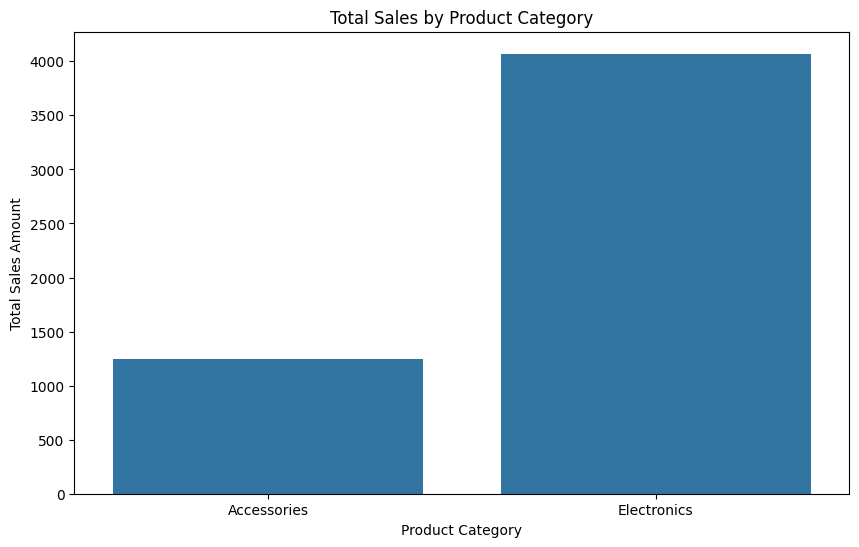

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Total_Amount', data=cleaned_df.groupby('Category')['Total_Amount'].sum().reset_index())
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.show()

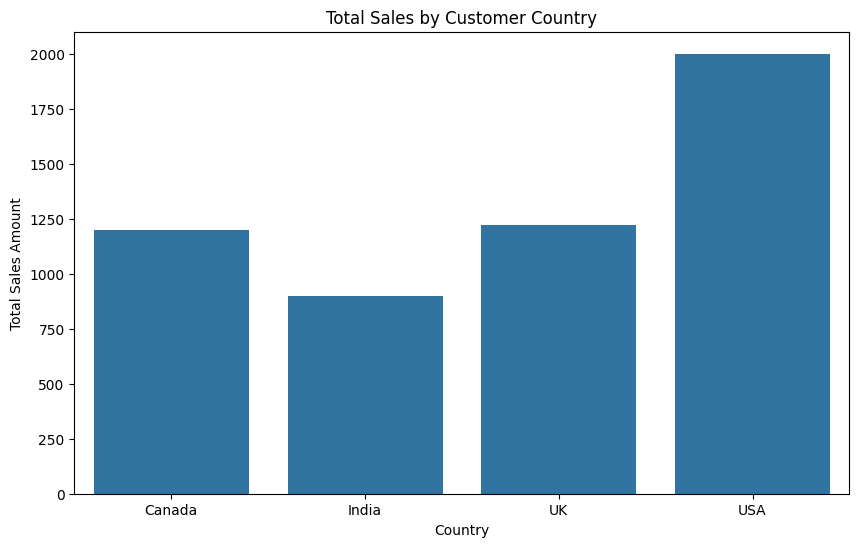

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='Total_Amount', data=cleaned_df.groupby('Country')['Total_Amount'].sum().reset_index())
plt.title('Total Sales by Customer Country')
plt.xlabel('Country')
plt.ylabel('Total Sales Amount')
plt.show()

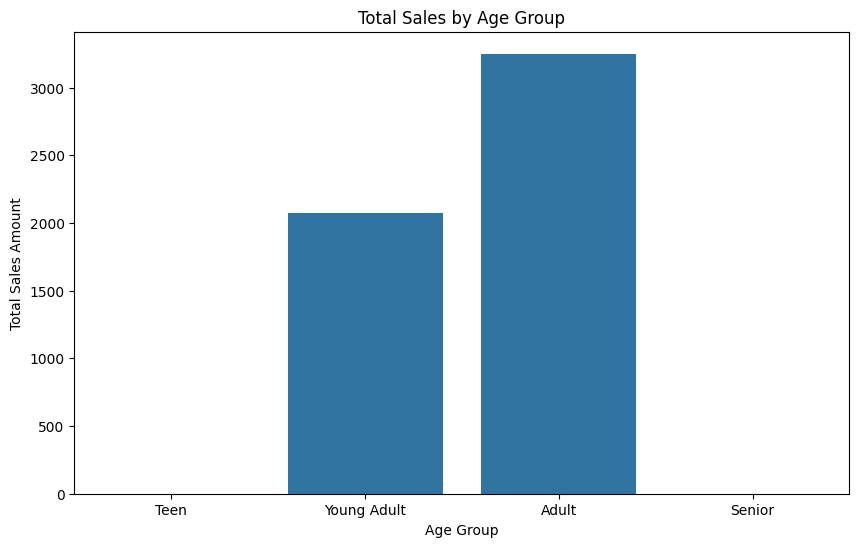

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Age_Group', y='Total_Amount', data=cleaned_df.groupby('Age_Group')['Total_Amount'].sum().reset_index(), order=['Teen', 'Young Adult', 'Adult', 'Senior'])
plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales Amount')
plt.show()

### Additional Visualizations

Let's continue our exploration with more detailed visualizations, focusing on gender, specific products, and customer ratings.

/tmp/ipykernel_1499/1296960705.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Total_Amount', data=cleaned_df.groupby('Gender')['Total_Amount'].sum().reset_index(), palette='pastel')


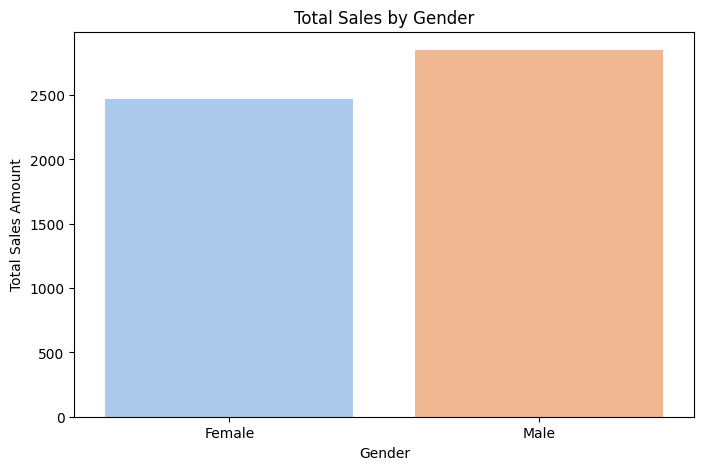

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='Gender', y='Total_Amount', data=cleaned_df.groupby('Gender')['Total_Amount'].sum().reset_index(), palette='pastel')
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales Amount')
plt.show()

/tmp/ipykernel_1499/1454872716.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product', y='Total_Amount', data=cleaned_df.groupby('Product')['Total_Amount'].sum().reset_index(), palette='viridis')


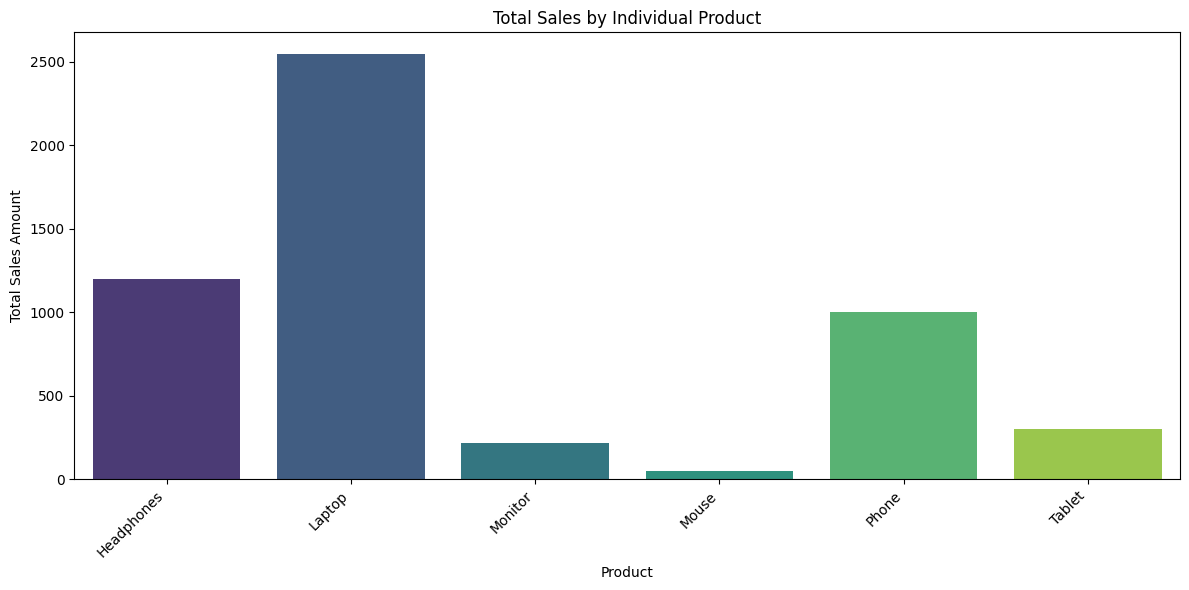

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Product', y='Total_Amount', data=cleaned_df.groupby('Product')['Total_Amount'].sum().reset_index(), palette='viridis')
plt.title('Total Sales by Individual Product')
plt.xlabel('Product')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1499/3082959509.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(cleaned_df['Rating'], bins=5, kde=True, palette='magma')


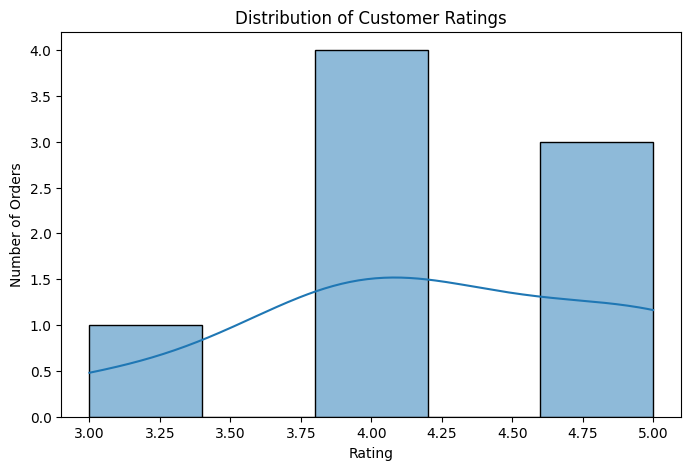

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(cleaned_df['Rating'], bins=5, kde=True, palette='magma')
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')
plt.show()

### Summary Statistics for Numerical Columns

In [13]:
print("Summary Statistics for Numerical Columns:")
display(cleaned_df.describe())

Summary Statistics for Numerical Columns:


,Order_ID,Age,Quantity,Price,Rating,Total_Amount,Month
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,6.000000
mean,1004.750000,33.140625,1.500000,499.375000,4.250000,665.000000,1.333333
std,2.815772,8.036590,0.755929,322.162753,0.707107,416.721901,0.516398
min,1001.000000,25.000000,1.000000,25.000000,3.000000,50.000000,1.000000
25%,1002.750000,28.500000,1.000000,280.000000,4.000000,280.000000,1.000000
50%,1004.500000,30.000000,1.000000,450.000000,4.000000,825.000000,1.000000
75%,1006.500000,36.000000,2.000000,812.500000,5.000000,925.000000,1.750000
max,1009.000000,46.125000,3.000000,900.000000,5.000000,1200.000000,2.000000


### Visualizing Summary Statistics with Box Plots

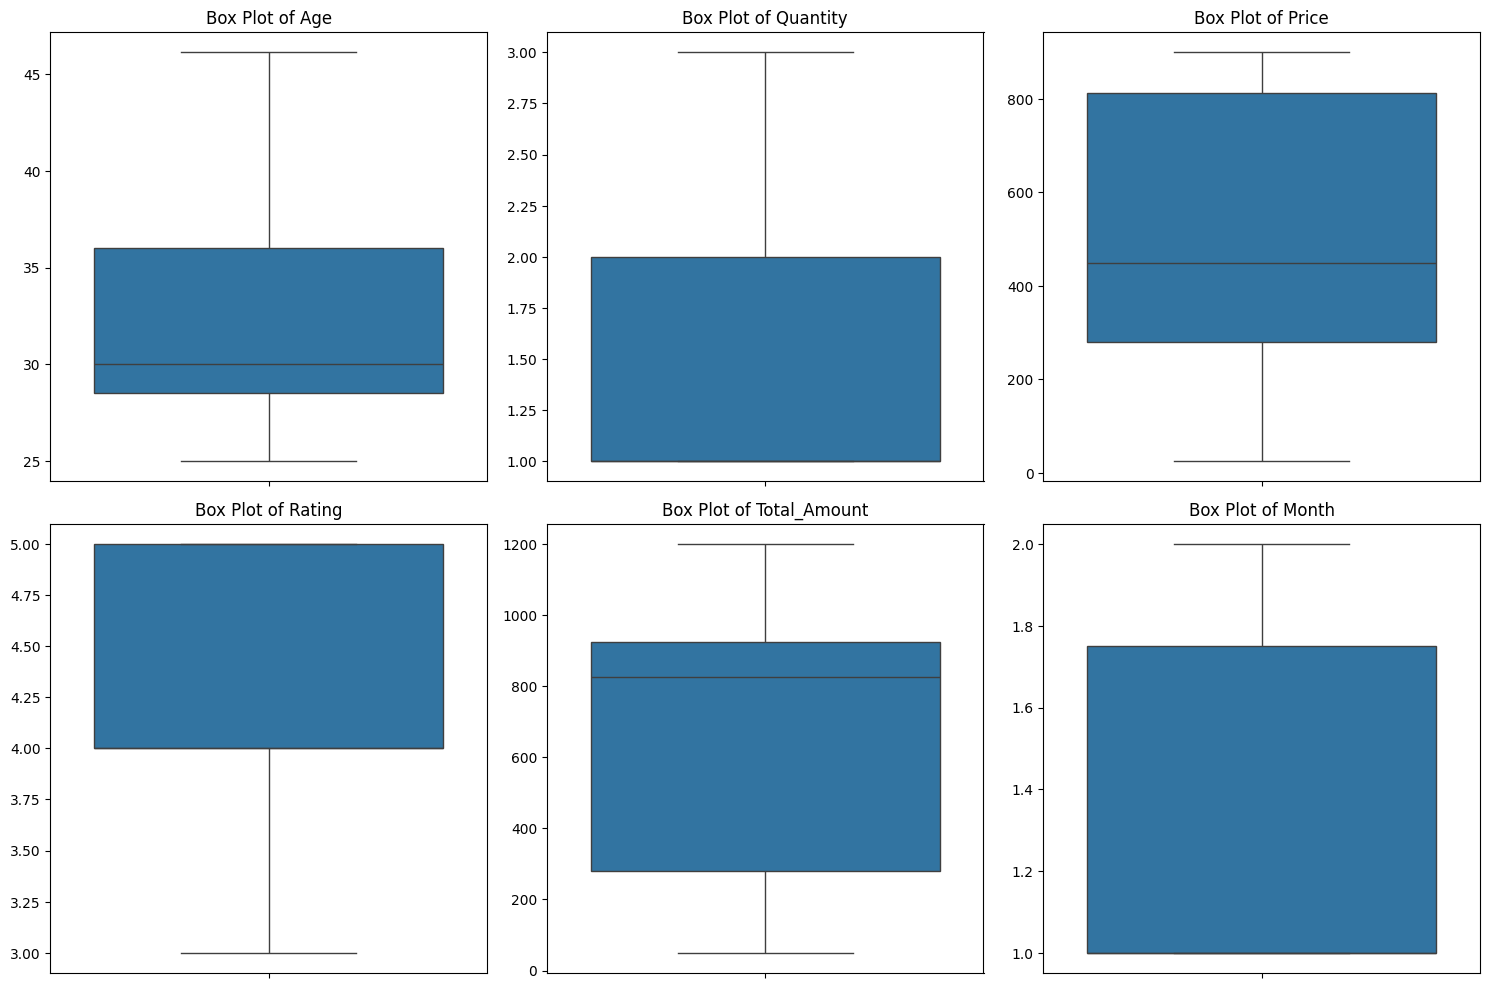

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'Quantity', 'Price', 'Rating', 'Total_Amount', 'Month']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.boxplot(y=cleaned_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove default y-label to avoid clutter

plt.tight_layout()
plt.show()